In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadtaha01
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


100%|██████████| 1.55k/1.55k [00:00<00:00, 4.56MB/s]

In [ ]:
df = pd.read_csv('/content/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print(df['Gender'].unique())

[1 0]


In [ ]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]
print(X)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [ ]:
Scaler = StandardScaler()
X_Scaler = Scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_Scaler)

KMeans(n_clusters=3, random_state=0)

In [ ]:
labels = kmeans.labels_
df['Cluster Labels'] = labels

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Labels
0,1,1,19,15,39,0
1,2,1,21,15,81,0
2,3,0,20,16,6,0
3,4,0,23,16,77,0
4,5,0,31,17,40,0


In [ ]:
print(df['Cluster Labels'].unique())

[0 1 2]


In [ ]:
print(df.groupby('Cluster Labels').mean())

                CustomerID  ...  Spending Score (1-100)
Cluster Labels              ...                        
0                     62.0  ...               49.829268
1                    162.0  ...               82.128205
2                    162.0  ...               18.631579

[3 rows x 5 columns]


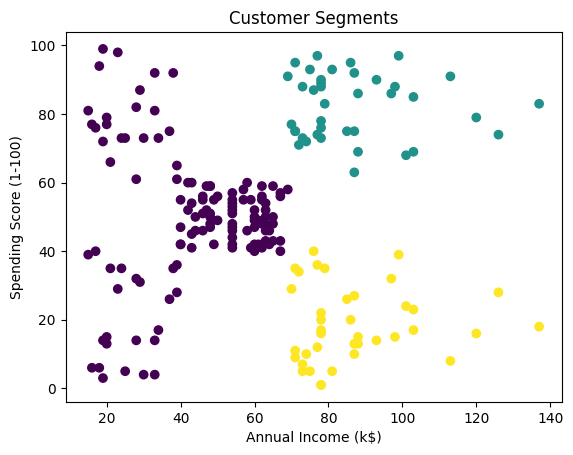

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster Labels'], cmap='viridis')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.show()

In [ ]:
df.groupby('Cluster Labels')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster Labels,,
0,44.154472,49.829268
1,86.538462,82.128205
2,87.000000,18.631579


**This is section is for checking the results using DBSCAN Algorithm**

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
# Run DBSCAN
db = DBSCAN(eps=1.5, min_samples=4)
db.fit(X_Scaler)

# Add cluster labels to the original DataFrame
df['DBSCAN Clusters'] = db.labels_

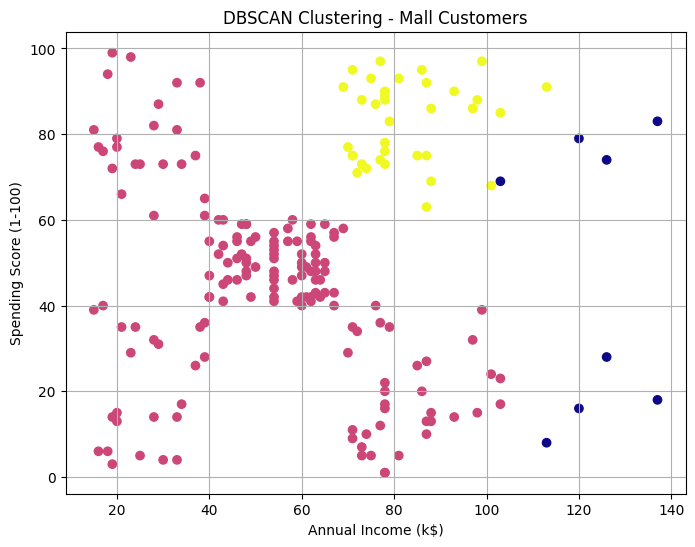

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='plasma')
plt.title('DBSCAN Clustering - Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.show()